# Gaia DR4 pre-release

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST


In [3]:
np.random.seed(42)

In [4]:
source_id = 1457486023639239296  # Gaia-4
primary_mass = (0.644, 0.025)  # (Msun)

By setting `gaia_release="DR3"`, the epoch astrometry data is cropped to the end date of DR3. This enables testing if we get a similar RUWE and orbital parameters as in the actual DR3 catalog.

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release="DR3", verbose=True)
epoch_astrom.retrieve_dr4_prelease(source_id=source_id, exclude_outliers=True, combine_ccds=True)


----------------
Epoch astrometry
----------------

Gaia release: DR3
Reference epoch: 2016.0

Primary mass (Msun): 0.64 +/- 0.03

---------------
Querying source
---------------

Gaia release: DR3
Source ID: 1457486023639239296



/Users/tomasstolker/code/exogaia/exogaia/data.py:1062: UserWarning: By setting 'gaia_release' to 'DR3', the DR4 epoch astrometry will be cropped to an end date of {self.time_end}.
  warnings.warn(


INFO: Query finished. [astroquery.utils.tap.core]

RA = 209.506 deg +/- 0.013 mas
Dec = 31.695 deg +/- 0.013 mas
Parallax = 13.545 +/- 0.021 mas
Proper motion in RA = -75.412 +/- 0.020 mas/yr
Proper motion in Dec = 18.063 +/- 0.016 mas/yr
G-band magnitude = 11.909
Pseudocolor = 1.39 um-1

UWE = 1.97
RUWE = 1.50
Astrometric excess noise (mas) = 0.1563 +/- 0.0045
Non single star = 1

---------------------------
Retrieving epoch astrometry
---------------------------

Gaia release: DR3
Reference epoch: 2016.0
Source ID: 1457486023639239296

Primary mass (Msun): 0.64 +/- 0.03

Data file: /Users/tomasstolker/.exogaia/GAIA_DR4_PRERELEASE_EPOCH_ASTROMETRY_RAW.xml
Data shape: (1008, 37)

Source IDs:
[np.int64(4181040337841125632), np.int64(435469040545191680), np.int64(3926186255616949504), np.int64(2309425390592896), np.int64(20694084440761600), np.int64(1663617687609809280), np.int64(2237987199365376), np.int64(60730287810150016), np.int64(10973744521070720), np.int64(4318465066420528000), n

In [6]:
print(epoch_astrom)

          transit_id  obs_time_tcb  scan_pos_angle  centroid_pos_al  centroid_pos_error_al  parallax_factor_al  sin_scan_ang  cos_scan_ang  relative_time_year  relative_time_day
0  16390666388267148   2014.635895       27.324787        46.465283               0.253592           -0.469124      0.459034      0.888419           -1.364105        -498.239286
1  16394758676214367   2014.636098       27.278814        46.751124               0.163191           -0.469118      0.458321      0.888787           -1.363902        -498.165279
2  16404499472734022   2014.636580       27.169090        47.009310               0.150494           -0.469102      0.456618      0.889663           -1.363420        -497.989113
3  16408591767097653   2014.636783       27.122862        46.399506               0.179624           -0.469094      0.455900      0.890031           -1.363217        -497.915162
4  16418332574234133   2014.637265       27.012600        45.717743               0.184429           -0.469074

In [7]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 1.353

Best-fit stellar track:
   - RA offset (mas) = 113.220 +/- 0.015
   - Dec offset (mas) = -26.752 +/- 0.013
   - Parallax (mas) = 13.662 +/- 0.017
   - mu in RA (mas/yr) = -75.562 +/- 0.018
   - mu in Dec (mas/yr) = 17.922 +/- 0.013

Best-fit orbit:
   - Period (days) = 529.832
   - Eccentricity = 0.433
   - Relative time of periastron = 0.97
   - Thiele-Innes A = 0.265 +/- 0.016
   - Thiele-Innes B = -0.052 +/- 0.013
   - Thiele-Innes F = -0.023 +/- 0.013
   - Thiele-Innes G = -0.136 +/- 0.018

Derived parameters:
   - Semi-major axis of photocenter (mas) = 0.270 +/- 0.016
   - Relative semi-major axis (au) = 1.113
   - Mass function (Msun) = 3.687e-06
   - Companion mass (Msun) = 1.166e-02

Conversion to campbell elements:
   - Period = 529.832 days
   - Eccentricity = 0.433
   - Relative time of periastron = 0.967
   - Semi-major axis of photocenter (mas) = 0.270
   - Inclination (deg) = 120.584
   - Argument of periastron (deg) = 179.051
   - PA of ascending 

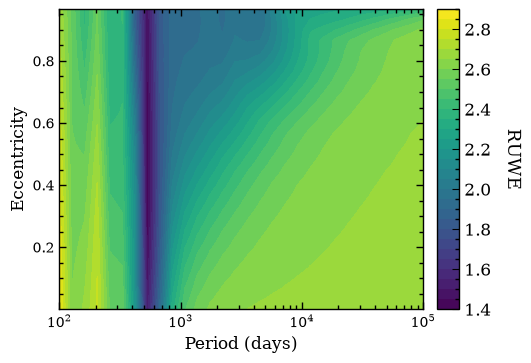

In [8]:
fig = leastsq.orbit_grid(map_type='ruwe', plot_file='plot.png', n_points=30)


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 1.949
RUWE: 1.061

Best-fit stellar track:
   - RA offset (mas) = 113.217 +/- 0.030
   - Dec offset (mas) = -26.770 +/- 0.051
   - Parallax (mas) = 13.655 +/- 0.019
   - mu in RA (mas/yr) = -75.558 +/- 0.019
   - mu in Dec (mas/yr) = 17.929 +/- 0.014

Best-fit orbit:
   - Period (days) = 537.103 +/- 8.576
   - Eccentricity = 0.397 +/- 0.118
   - Relative time of periastron = 0.983 +/- 0.039
   - Semi-major axis of photocenter (mas) = 0.268 +/- 0.019
   - Inclination (deg) = 121.293 +/- 4.198
   - Argument of periastron (deg) = 185.617 +/- 16.616
   - PA of ascending node (deg) = 169.078 +/- 4.369
   - Jitter (mas) = 0.022 +/- 0.001

Number of function evaluations: 42
Number of Jacobian evaluations: 42

Derived parameters:
   - Relative semi-major axis (au) = 1.123
   - Mass function (Msun) = 3.477e-06
   - Companion mass (Msun) = 1.143e-02


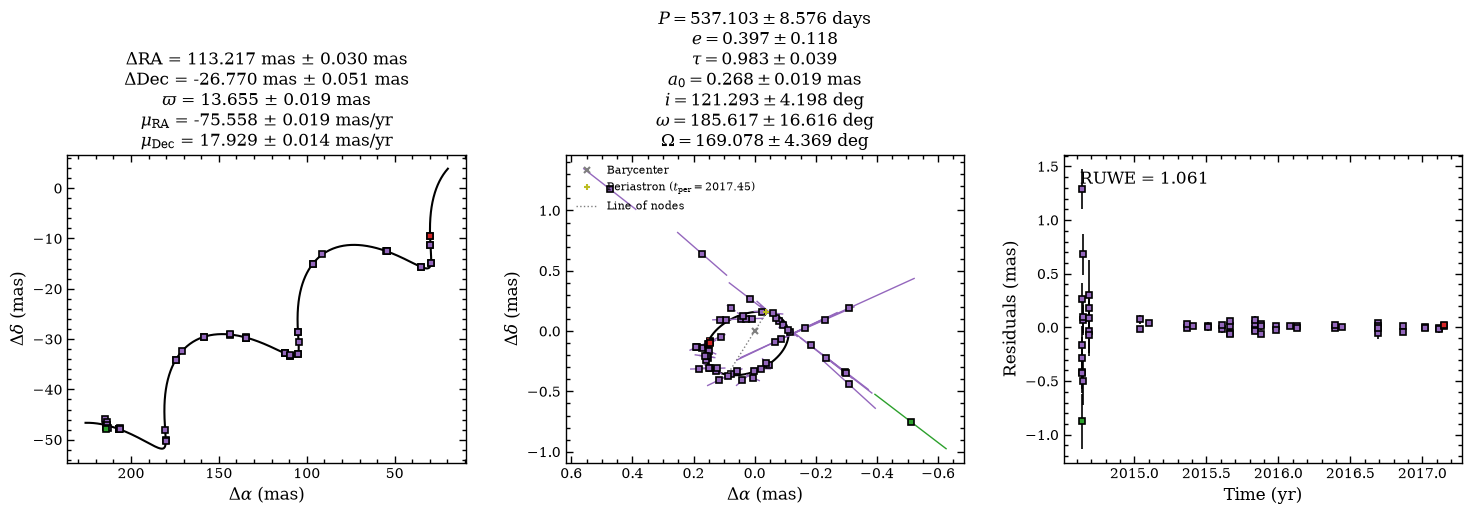

In [9]:
fig = leastsq.orbit_fit(inc_jitter=True, plot_file='plot.png')

In [10]:
print(leastsq)

LeastSquares(Δα = 113.217 mas, Δδ = -26.7705 mas, ϖ = 13.6546 mas, μ_α = -75.5578 mas/yr, μ_δ = 17.9292 mas/yr, P = 537.103 days, e = 0.397174, τ = 0.983133, a = 0.267501 mas, i = 2.11696 rad, ω = 3.23962 rad, Ω = 2.95097 rad)
